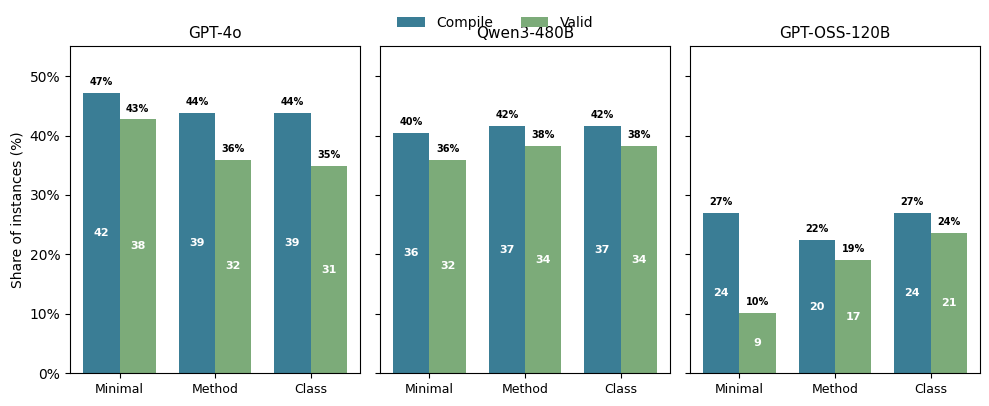

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 89
models = ['GPT-4o', 'Qwen3-480B', 'GPT-OSS-120B']
ctxs = ['Minimal', 'Method', 'Class']
compile_ct = {'GPT-4o':[42,39,39], 'Qwen3-480B':[36,37,37], 'GPT-OSS-120B':[24,20,24]}
valid_ct   = {'GPT-4o':[38,32,31], 'Qwen3-480B':[32,34,34], 'GPT-OSS-120B':[9,17,21]}

x = np.arange(3)
w = 0.38
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

def annotate(ax, bars, counts):
    for rect, c in zip(bars, counts):
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 1,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')
        if h > 6:  # count inside the bar
            ax.text(rect.get_x() + rect.get_width()/2, h/2,
                    str(c), ha='center', va='center', color='white',
                    fontsize=8, fontweight='bold')

for ax, m in zip(axes, models):
    cp = [c/N*100 for c in compile_ct[m]]
    vp = [v/N*100 for v in valid_ct[m]]
    b1 = ax.bar(x - w/2, cp, w, label='Compile', color='#3a7d95')
    b2 = ax.bar(x + w/2, vp, w, label='Valid', color='#7cab79')
    annotate(ax, b1, compile_ct[m])
    annotate(ax, b2, valid_ct[m])
    ax.set_title(m, fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(ctxs, fontsize=9)
    ax.set_ylim(0, 55)
    ax.grid(False)

axes[0].set_ylabel('Share of instances (%)')
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v:.0f}%')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig('rq1_instance_pct_count_subplots.pdf', bbox_inches='tight')
plt.savefig('rq1_instance_pct_count_subplots.png', dpi=300, bbox_inches='tight')

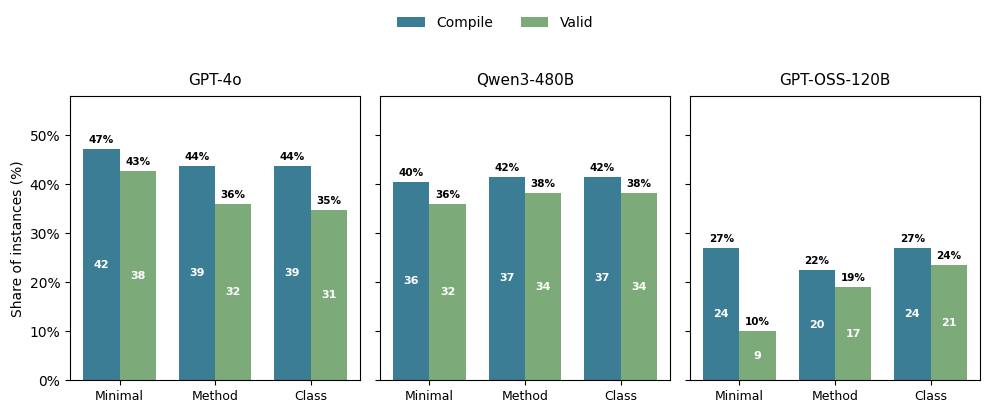

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 89
models = ['GPT-4o', 'Qwen3-480B', 'GPT-OSS-120B']
ctxs = ['Minimal', 'Method', 'Class']
compile_ct = {'GPT-4o':[42,39,39], 'Qwen3-480B':[36,37,37], 'GPT-OSS-120B':[24,20,24]}
valid_ct   = {'GPT-4o':[38,32,31], 'Qwen3-480B':[32,34,34], 'GPT-OSS-120B':[9,17,21]}

x = np.arange(3)
w = 0.38
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

def annotate(ax, bars, counts):
    for rect, c in zip(bars, counts):
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.8,
                f'{h:.0f}%', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold', clip_on=False)
        if h > 6:
            ax.text(rect.get_x() + rect.get_width()/2, h/2,
                    str(c), ha='center', va='center', color='white',
                    fontsize=8, fontweight='bold')
        else:  # too short for an inside label
            ax.text(rect.get_x() + rect.get_width()/2, h + 4.5,
                    str(c), ha='center', va='center', color='#4a4a4a', fontsize=7)

for ax, m in zip(axes, models):
    cp = [c/N*100 for c in compile_ct[m]]
    vp = [v/N*100 for v in valid_ct[m]]
    b1 = ax.bar(x - w/2, cp, w, label='Compile', color='#3a7d95')
    b2 = ax.bar(x + w/2, vp, w, label='Valid', color='#7cab79')
    annotate(ax, b1, compile_ct[m])
    annotate(ax, b2, valid_ct[m])
    ax.set_title(m, fontsize=11, pad=8)
    ax.set_xticks(x); ax.set_xticklabels(ctxs, fontsize=9)
    ax.set_ylim(0, 58)
    ax.margins(y=0)
    ax.grid(False)

axes[0].set_ylabel('Share of instances (%)')
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v:.0f}%')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, frameon=False,
           loc='lower center', bbox_to_anchor=(0.5, 0.94), fontsize=10)

# reserve top space for the legend so it never overlaps the titles
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('rq1_instance_pct_count_subplots.pdf', bbox_inches='tight')
plt.savefig('rq1_instance_pct_count_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/5j/383lm0896fj7zjtxk6zgp95r0000gs/T/ipykernel_84181/798881393.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


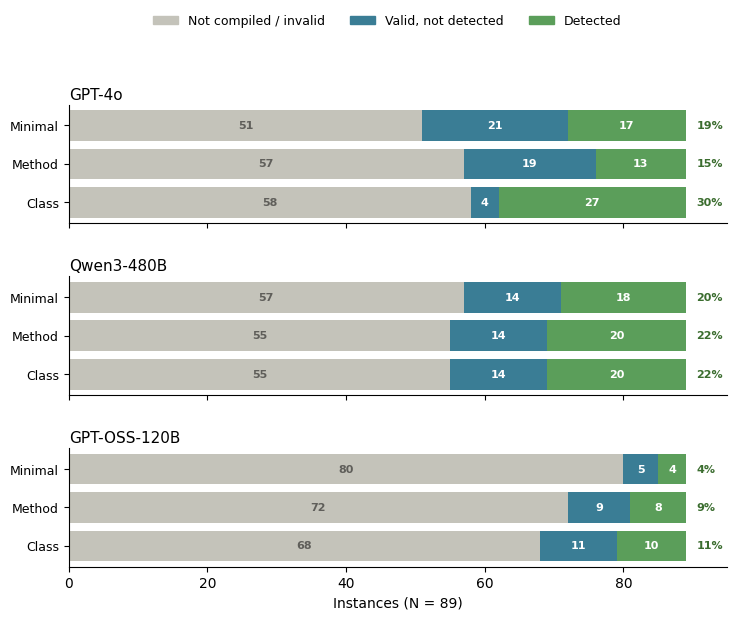

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 89
data = {
    'GPT-4o':       [('Minimal',38,17), ('Method',32,13), ('Class',31,27)],
    'Qwen3-480B':   [('Minimal',32,18), ('Method',34,20), ('Class',34,20)],
    'GPT-OSS-120B': [('Minimal',9,4),   ('Method',17,8),  ('Class',21,10)],
}
models = list(data)
fig, axes = plt.subplots(len(models), 1, figsize=(8.5, 6), sharex=True,
                         gridspec_kw={'hspace': 0.45})

for ax, m in zip(axes, models):
    rows = data[m]
    labels = [r[0] for r in rows]
    not_comp    = [N - r[1] for r in rows]
    valid_undet = [r[1] - r[2] for r in rows]
    detected    = [r[2] for r in rows]
    rates       = [round(r[2]/N*100) for r in rows]
    y = np.arange(len(rows))[::-1]

    p1 = ax.barh(y, not_comp, color='#c4c3ba')
    p2 = ax.barh(y, valid_undet, left=not_comp, color='#3a7d95')
    p3 = ax.barh(y, detected, left=np.add(not_comp, valid_undet), color='#5b9e5a')

    def seg(bars, vals, dark=False):
        for rect, v in zip(bars, vals):
            if v > 0 and rect.get_width() > 2.5:
                ax.text(rect.get_x() + rect.get_width()/2, rect.get_y() + rect.get_height()/2,
                        str(v), ha='center', va='center',
                        color='#5f5e5a' if dark else 'white', fontsize=8, fontweight='bold')
    seg(p1, not_comp, dark=True); seg(p2, valid_undet); seg(p3, detected)

    for rect, r in zip(p3, rates):   # detection rate at the end
        ax.text(rect.get_x() + rect.get_width() + 1.5, rect.get_y() + rect.get_height()/2,
                f'{r}%', ha='left', va='center', color='#3b6d2f', fontsize=8, fontweight='bold')

    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(m, fontsize=11, loc='left', pad=4)
    ax.set_xlim(0, N + 6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(False)

axes[-1].set_xlabel('Instances (N = 89)')

handles = [plt.Rectangle((0,0),1,1,color=c) for c in ('#c4c3ba','#3a7d95','#5b9e5a')]
fig.legend(handles, ['Not compiled / invalid', 'Valid, not detected', 'Detected'],
           ncol=3, frameon=False, loc='lower center', bbox_to_anchor=(0.5, 0.99), fontsize=9)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('rq2_instance_funnel_panels.pdf', bbox_inches='tight')
plt.savefig('rq2_instance_funnel_panels.png', dpi=300, bbox_inches='tight')